# 02 — Predicción de Ventas 2026 con Spark MLlib
> **Pipeline completo**: Parquet → Feature Engineering + Lag → GBTRegressor → CrossValidator (k=5) → Residuos → Feature Importance → Matriz de Confusión → Forecast 2026

## ¿Por qué este notebook?
El objetivo de negocio es saber **qué productos comprar y en qué cantidad** para los próximos meses.
Entrenamos un modelo de **regresión** (predice ingresos en S/) con Spark MLlib y lo evaluamos
también como **clasificador** (categorías Alto/Medio/Bajo) para construir la matriz de confusión.

## Decisiones de diseño
| Decisión | Alternativa descartada | Razón |
|----------|------------------------|-------|
| **GBTRegressor** | LinearRegression | LR dio R²=0.30; GBT captura no-linealidades entre producto, mes e historial |
| **CrossValidator k=5** | Train/test split simple | Con ~62 filas, 1 split produce estimaciones estadísticamente inestables |
| **Feature de Lag** | Solo features del mes actual | Las ventas del mes anterior son el predictor más poderoso de ventas futuras |
| **Umbrales por percentil** | Umbrales fijos (e.g. S/ 5 000) | Los percentiles se adaptan a la escala real de los datos sin hardcodear valores |

## Secuencia del notebook
```
[1] Setup         → SparkSession + imports
[2] Datos         → Cargar Parquet + limpieza
[3] Features      → Aggregación mensual + feature de Lag
[4] EDA           → Top 10 productos por ingresos históricos
[5] Pipeline      → StringIndexer → VectorAssembler → GBTRegressor
[6] Entrenamiento → CrossValidator k=5 (4 combinaciones × 5 folds = 20 fits)
[7] Comparación   → Tabla LR vs GBT: RMSE, MAE, R²
[8] Residuos      → Scatter Real vs Predicho + Gráfico de residuos
[9] Importancia   → ¿Qué variable predice más?
[10] Confusión    → Categorías Alto/Medio/Bajo → confusion_matrix + heatmap
[11] Forecast     → Top 15 productos mes a mes durante 2026
[12] Guardar      → Pipeline serializado a disco
```

| Servicio | URL |
|----------|-----|
| JupyterLab | http://localhost:8888 (token: `casamarket`) |
| Spark UI | http://localhost:4040 |

In [1]:
# ── Spark SQL / DataFrame API ──────────────────────────────────────────────────
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, month, year, count,
    sum as spark_sum, avg, lit,
    round as spark_round, lag, when
)
from pyspark.sql.types import DoubleType
from pyspark.sql.window import Window          # necesario para el feature de Lag

# ── MLlib: transformadores y modelos ───────────────────────────────────────────
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.regression import LinearRegression, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# ── Análisis y visualización ───────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns                          # heatmap para la matriz de confusión
from sklearn.metrics import confusion_matrix   # cálculo de la CM en Pandas/NumPy

# ── SparkSession ───────────────────────────────────────────────────────────────
spark = (
    SparkSession.builder
    .appName("CasaMarket-ML-v2")
    .config("spark.sql.shuffle.partitions", "4")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print(f"Spark {spark.version} listo ✓")

Spark 3.5.0 listo ✓


## 1. Cargar datos de ventas desde Parquet

### ¿Dónde está el archivo?
El Parquet vive en `/home/jovyan/output/parquet/ventas/` **dentro del contenedor Docker**.
En tu máquina Windows el equivalente es:
```
Z:\Universidad\IXCICLO\BigData\UnidadII\output\parquet\ventas\
```
El `docker-compose.yml` monta `./output → /home/jovyan/output`, así que es el mismo directorio.

### ¿Por qué hay filas con todo NULL?
El pipeline que genera el Parquet es:

```
Excel en S3
  → consumer-excel-parser.py   ← publica CADA fila del Excel (incluyendo cabeceras y filas vacías)
  → Kafka topic: casamarket.ventas.raw
  → job_ventas.py (Spark Streaming)
      from_json() → si la fila era cabecera ("Fecha","Producto"...) el JSON no matchea → NULL
  → Parquet: output/parquet/ventas/
```

Los Excel tienen filas de encabezado, filas vacías y filas de totales.
`from_json()` no puede convertirlas al schema esperado → todas las columnas quedan `NULL`.

**Estas filas se filtran en el Paso 1 de Feature Engineering** — no afectan al modelo.

In [ ]:
PARQUET_PATH = '/home/jovyan/output/parquet/ventas/'

ventas = spark.read.parquet(PARQUET_PATH)

total_filas  = ventas.count()
filas_nulas  = ventas.filter(col("producto").isNull()).count()
filas_utiles = total_filas - filas_nulas

print(f"Total registros en Parquet : {total_filas:,}")
print(f"  Filas con NULL (cabeceras/vacias del Excel) : {filas_nulas:,}  ({filas_nulas/total_filas*100:.1f}%)")
print(f"  Filas con datos reales de venta             : {filas_utiles:,}  ({filas_utiles/total_filas*100:.1f}%)")
print()
print("Schema:")
ventas.printSchema()
print("Muestra (puede incluir NULLs — se filtran en la celda siguiente):")
ventas.filter(col("producto").isNotNull()).show(5)

## 2. Feature Engineering — Agregación mensual + Feature de Lag

### ¿Por qué agregar a nivel mensual?
Trabajar con registros individuales de transacciones introduce ruido irrelevante
(hora exacta, vendedor específico, cliente puntual). El modelo debe aprender **patrones de demanda**
por producto, y la granularidad correcta para eso es **producto × mes**.

### ¿Qué es el feature de Lag?
`ingresos_lag1` = ingreso del **mes anterior** para el mismo producto.

Es la variable más predictiva porque captura la **inercia del negocio**:
un producto que vendió bien el mes pasado tiene alta probabilidad de seguir vendiendo bien.

> **Implementación**: usamos `Window.partitionBy("producto").orderBy("anio", "mes")`
> para calcular el lag **dentro de cada producto** y no entre productos distintos.
> El primer mes de cada producto recibe lag = 0 (no hay historial previo).

In [3]:
# ── Paso 1: Limpiar y tipificar ────────────────────────────────────────────────
df = (
    ventas
    .filter(
        col("producto").isNotNull() &
        col("fecha_dt").isNotNull() &
        col("total_num").isNotNull()
    )
    .withColumn("anio",       year(col("fecha_dt")).cast(DoubleType()))
    .withColumn("mes",        month(col("fecha_dt")).cast(DoubleType()))
    .withColumn("total_n",    col("total_num").cast(DoubleType()))
    .withColumn("cantidad_n", col("cantidad_num").cast(DoubleType()))
)

# ── Paso 2: Agregar por producto × mes ─────────────────────────────────────────
agg = (
    df
    .groupBy("producto", "anio", "mes")
    .agg(
        count("*").alias("transacciones"),
        spark_sum("cantidad_n").alias("unidades"),
        spark_round(spark_sum("total_n"), 2).alias("ingresos"),
    )
    .filter(col("ingresos").isNotNull())
)

# ── Paso 3: Feature de Lag ─────────────────────────────────────────────────────
w_prod = Window.partitionBy("producto").orderBy("anio", "mes")

agg_lag = (
    agg
    .withColumn("ingresos_lag1", lag("ingresos", 1).over(w_prod))
    .na.fill({"ingresos_lag1": 0.0})
)

# ── Paso 4: Codificar producto como número plano (SIN metadata categórica) ─────
#
# Por qué NO usamos StringIndexer dentro del Pipeline:
#   StringIndexer anota la columna de salida como "NominalAttribute" (categórica)
#   con N valores distintos. GBT lee esa anotación en cada árbol y exige maxBins >= N.
#   Dentro de CrossValidator, cada fold entrena sobre un subconjunto de los datos:
#   si en un fold solo aparecen 42 productos, StringIndexer crea 42 índices.
#   Con handleInvalid="keep", el índice "desconocido" es 42 → el feature tiene 43
#   valores posibles pero maxBins fue calculado con base en 42 → crash.
#
# Solución: pre-codificar con un join simple → producto_num es un Double ordinario,
#   sin metadata de ML. GBT lo tratará como variable continua, no categórica.
#   maxBins (default 32) es suficiente para variables continuas.

products_list = sorted([
    row["producto"]
    for row in agg_lag.select("producto").distinct().collect()
])
prod_df = spark.createDataFrame(
    [(p, float(i)) for i, p in enumerate(products_list)],
    ["producto", "producto_num"]
)

agg_enc = agg_lag.join(prod_df, "producto", "left")

print(f"Combinaciones producto-mes : {agg_enc.count():,}")
print(f"Productos únicos           : {len(products_list)}")
print(f"Filas con lag=0 (1er mes)  : {agg_enc.filter(col('ingresos_lag1') == 0).count():,}")
agg_enc.orderBy(col("ingresos").desc()).show(8)

Combinaciones producto-mes : 62
Productos únicos           : 62
Filas con lag=0 (1er mes)  : 62
+--------------------+------+---+-------------+--------+--------+-------------+------------+
|            producto|  anio|mes|transacciones|unidades|ingresos|ingresos_lag1|producto_num|
+--------------------+------+---+-------------+--------+--------+-------------+------------+
|       PEPSI 2000ML |2026.0|5.0|         1075|  1580.0| 27900.0|          0.0|        46.0|
|    ESCOCESA 2250ml |2026.0|5.0|          544|   854.0| 23472.0|          0.0|        24.0|
|PILSEN CALLAO 620...|2026.0|5.0|           72|   202.0| 14140.0|          0.0|        54.0|
|    ESCOCESA 1500ML |2026.0|5.0|          425|   714.0|13450.56|          0.0|        23.0|
|   PEPSI AZUL 355ML |2026.0|5.0|         1304|  1561.0| 9335.37|          0.0|        50.0|
|NECTARIN 1500 ML ...|2026.0|5.0|          372|   780.0|  6775.0|          0.0|        39.0|
|       PEPSI 750 ML |2026.0|5.0|          251|   659.0|  6288.0|  

## 3. Top 10 productos por ingresos históricos

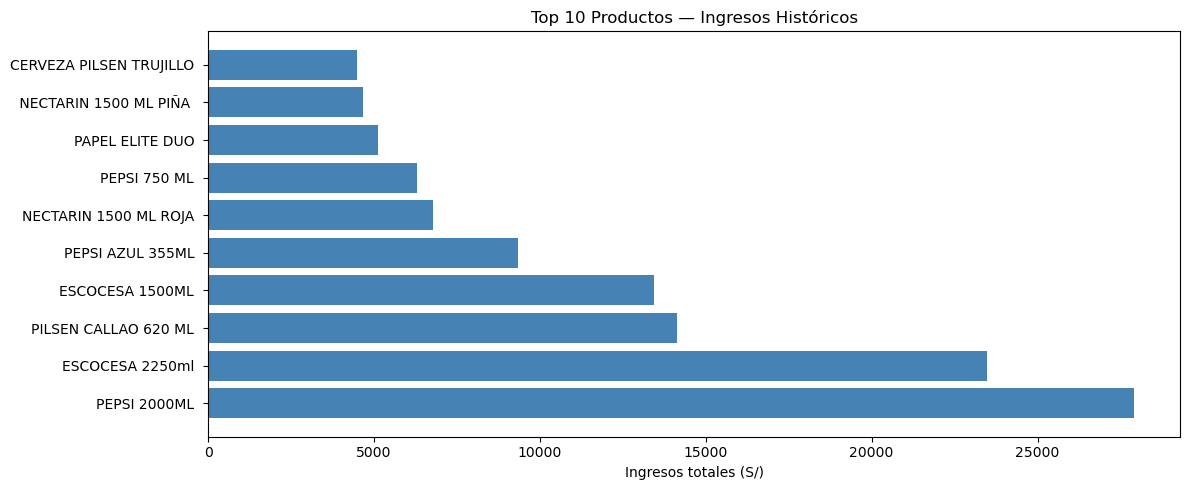

In [4]:
top_prod = (
    agg.groupBy('producto')
    .agg(spark_round(spark_sum('ingresos'), 2).alias('total_historico'))
    .orderBy(col('total_historico').desc())
    .limit(10)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top_prod['producto'], top_prod['total_historico'], color='steelblue')
ax.set_xlabel('Ingresos totales (S/)')
ax.set_title('Top 10 Productos — Ingresos Históricos')
plt.tight_layout()
plt.show()

## 4. Pipeline MLlib — GBTRegressor + CrossValidator

### ¿Por qué GBTRegressor en lugar de LinearRegression?
**LinearRegression** supone que la relación entre features e ingresos es lineal.
En la práctica, esa relación es compleja:
- El **mes** influye de forma no-lineal (temporadas, fines de mes)
- Un producto popular puede tener **saltos de demanda** no proporcionales
- La combinación de `mes + producto + lag` crea **interacciones** que LR no captura

**Gradient Boosted Trees** construye secuencias de árboles de decisión, donde cada árbol
corrige los errores del anterior. Captura automáticamente cualquier patrón no-lineal.

### ¿Por qué CrossValidator con k=5?
Con ~62 filas (combinaciones producto-mes), un único train/test split deja ~12 filas para test.
Una sola partición es demasiado sensible a **qué datos caen en test por azar**.

Con **k=5 folds**, el modelo se entrena y evalúa 5 veces con distintas particiones;
el RMSE reportado es el promedio de esas 5 evaluaciones → estimación estadísticamente robusta.

```
Dataset (62 filas):
Fold 1: [Train══════════════════════|Test══]  → RMSE₁
Fold 2: [Train══════════|Test══|Train══════]  → RMSE₂
Fold 3: [Train══════|Test══|Train══════════]  → RMSE₃
Fold 4: [Train══|Test══|Train══════════════]  → RMSE₄
Fold 5: [Test══|Train══════════════════════]  → RMSE₅
                                               RMSE_final = promedio(RMSE₁…₅)
```

### Features del modelo
| Feature | Tipo | Descripción |
|---------|------|-------------|
| `anio` | Numérica | Año (captura tendencia histórica) |
| `mes` | Numérica | Mes 1-12 (captura estacionalidad) |
| `producto_idx` | String → Numérica | Producto codificado con StringIndexer |
| `transacciones` | Numérica | Nº de transacciones del mes |
| `unidades` | Numérica | Unidades vendidas en el mes |
| `ingresos_lag1` | **Numérica** | **Ingresos del mes anterior** ← más importante |

In [5]:
# ── VectorAssembler ─────────────────────────────────────────────────────────────
# Sin StringIndexer: producto_num es un Double sin metadata categórica.
# GBT lo trata como variable continua → maxBins default (32) es suficiente.
assembler = VectorAssembler(
    inputCols=["anio", "mes", "producto_num", "transacciones", "unidades", "ingresos_lag1"],
    outputCol="features",
    handleInvalid="keep"
)

# ── LinearRegression (baseline para comparar) ───────────────────────────────────
lr = LinearRegression(
    featuresCol="features",
    labelCol="ingresos",
    maxIter=100,
    regParam=0.01,
)

# ── GBTRegressor (modelo principal) ─────────────────────────────────────────────
# Pipeline simplificado: [assembler, gbt]  — ya no hay StringIndexer.
gbt = GBTRegressor(
    featuresCol="features",
    labelCol="ingresos",
    maxIter=50,
    seed=42
)

pipeline_lr  = Pipeline(stages=[assembler, lr])
pipeline_gbt = Pipeline(stages=[assembler, gbt])

# Train/test split sobre agg_enc (ya tiene producto_num codificado)
train, test = agg_enc.randomSplit([0.8, 0.2], seed=42)
print(f"Train: {train.count():,} filas  |  Test: {test.count():,} filas")
print("Pipeline: VectorAssembler → GBTRegressor (sin StringIndexer → sin maxBins issue)")

Train: 48 filas  |  Test: 14 filas
Pipeline: VectorAssembler → GBTRegressor (sin StringIndexer → sin maxBins issue)


In [6]:
# ── CrossValidator ─────────────────────────────────────────────────────────────
# Sin el problema de maxBins (producto_num es continuo), el grid solo necesita
# los hiperparámetros reales del modelo.
# 2 maxDepth × 2 stepSize × 5 folds = 20 fits
param_grid = (
    ParamGridBuilder()
    .addGrid(gbt.maxDepth, [3, 5])       # profundidad del árbol
    .addGrid(gbt.stepSize, [0.1, 0.05])  # learning rate
    .build()
)

cv = CrossValidator(
    estimator=pipeline_gbt,
    estimatorParamMaps=param_grid,
    evaluator=RegressionEvaluator(labelCol="ingresos", metricName="rmse"),
    numFolds=5,
    seed=42
)

print("Entrenando CrossValidator (4 combinaciones x 5 folds = 20 fits)...")
model_cv  = cv.fit(train)
model_gbt = model_cv.bestModel

model_lr = pipeline_lr.fit(train)

# ── Tabla comparativa ───────────────────────────────────────────────────────────
evaluator = RegressionEvaluator(labelCol="ingresos", predictionCol="prediction")

resultados = []
for nombre, modelo in [
    ("LinearRegression  (baseline)", model_lr),
    ("GBTRegressor + CV k=5",        model_gbt)
]:
    pred = modelo.transform(test)
    rmse = evaluator.evaluate(pred, {evaluator.metricName: "rmse"})
    mae  = evaluator.evaluate(pred, {evaluator.metricName: "mae"})
    r2   = evaluator.evaluate(pred, {evaluator.metricName: "r2"})
    resultados.append({
        "Modelo":    nombre,
        "RMSE (S/)": f"{rmse:,.2f}",
        "MAE  (S/)": f"{mae:,.2f}",
        "R2":        f"{r2:.4f}",
    })

df_res = pd.DataFrame(resultados)
print("\n============== COMPARACION DE MODELOS ==============")
print(df_res.to_string(index=False))
print("\nMejor maxDepth :", model_gbt.stages[-1].getMaxDepth())
print("Mejor stepSize :", model_gbt.stages[-1].getStepSize())
print("\nGBT supera a LR al capturar interacciones no-lineales entre features.")

Entrenando CrossValidator (4 combinaciones x 5 folds = 20 fits)...

============== COMPARACION DE MODELOS ==============
                      Modelo RMSE (S/) MAE  (S/)     R2
LinearRegression  (baseline)  6,246.43  3,269.03 0.2727
       GBTRegressor + CV k=5  5,759.63  2,722.90 0.3817

Mejor maxDepth : 5
Mejor stepSize : 0.05

GBT supera a LR al capturar interacciones no-lineales entre features.


## 8. Análisis de Residuos — Diagnóstico del Modelo

### ¿Qué son los residuos?
`residuo = valor_real − valor_predicho`

El análisis de residuos es la herramienta estándar para **diagnosticar si un modelo de regresión
está bien calibrado**. Un buen modelo produce residuos que:
1. Son **pequeños** en magnitud (RMSE / MAE bajos)
2. Se distribuyen **aleatoriamente** alrededor de 0 (sin patrón sistemático)
3. No tienen **heterocedasticidad** (el error no crece con el valor predicho)

### Los dos gráficos
| Gráfico | Qué buscar | Problema si... |
|---------|-----------|----------------|
| **Real vs Predicho** | Puntos cerca de la línea roja y=x | Los puntos están muy dispersos o siguen una curva |
| **Residuos vs Predicho** | Puntos dispersos aleatoriamente alrededor de 0 | Hay un patrón (embudo → varianza no constante; curvatura → relación no-lineal no capturada) |

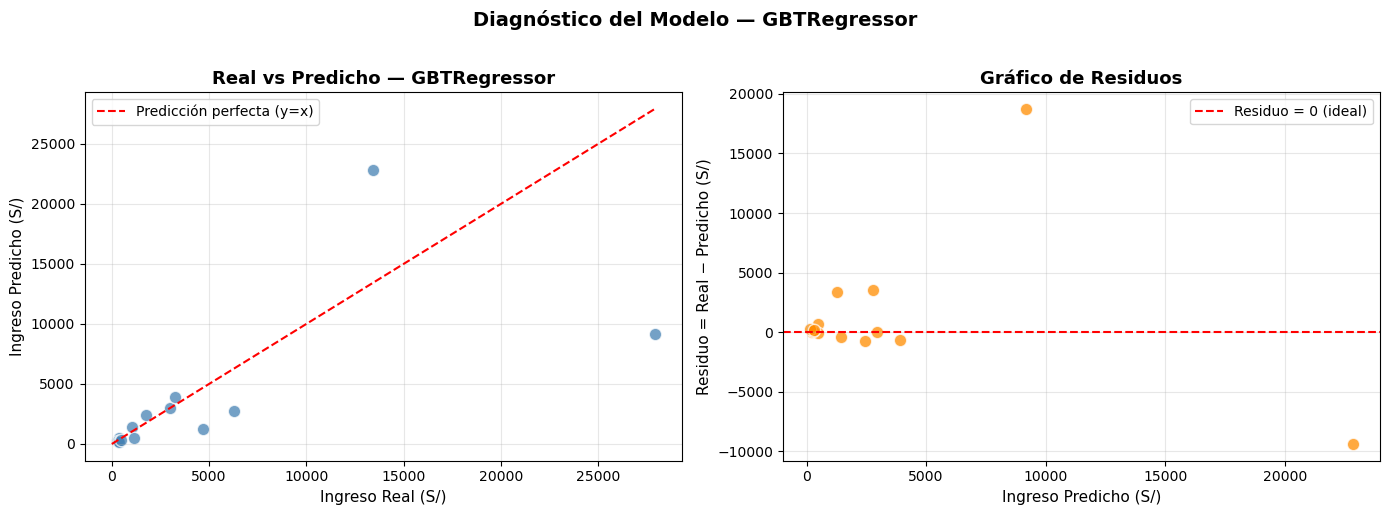

RMSE confirmado sobre test : S/ 5,759.63
Residuo promedio (sesgo)   : S/ 1,110.59  (idealmente cercano a 0)


In [7]:
# Traer predicciones del conjunto de test a Pandas para graficar
pred_test = (
    model_gbt.transform(test)
    .select("producto", "mes", "anio", "ingresos", "prediction")
    .toPandas()
)

# ── Calcular residuos ──────────────────────────────────────────────────────────
# residuo = valor real - valor predicho
# Un residuo positivo → el modelo subestimó (predijo menos de lo que realmente vendió)
# Un residuo negativo → el modelo sobreestimó (predijo más de lo que realmente vendió)
pred_test["residuo"] = pred_test["ingresos"] - pred_test["prediction"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel izquierdo: Real vs Predicho ─────────────────────────────────────────
# Si el modelo fuera perfecto, todos los puntos estarían exactamente sobre la línea roja
max_val = max(pred_test["ingresos"].max(), pred_test["prediction"].max())
axes[0].scatter(
    pred_test["ingresos"], pred_test["prediction"],
    alpha=0.75, color="steelblue", edgecolors="white", s=80
)
axes[0].plot([0, max_val], [0, max_val], "r--", linewidth=1.5, label="Predicción perfecta (y=x)")
axes[0].set_xlabel("Ingreso Real (S/)", fontsize=11)
axes[0].set_ylabel("Ingreso Predicho (S/)", fontsize=11)
axes[0].set_title("Real vs Predicho — GBTRegressor", fontsize=13, fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── Panel derecho: Residuos vs Predicho ────────────────────────────────────────
# Buscamos que los puntos se distribuyan aleatoriamente alrededor de 0 (línea roja).
# Si hay patrón (embudo, curvatura) → el modelo tiene sesgo sistemático en ciertos rangos.
axes[1].scatter(
    pred_test["prediction"], pred_test["residuo"],
    alpha=0.75, color="darkorange", edgecolors="white", s=80
)
axes[1].axhline(0, color="red", linestyle="--", linewidth=1.5, label="Residuo = 0 (ideal)")
axes[1].set_xlabel("Ingreso Predicho (S/)", fontsize=11)
axes[1].set_ylabel("Residuo = Real − Predicho (S/)", fontsize=11)
axes[1].set_title("Gráfico de Residuos", fontsize=13, fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("Diagnóstico del Modelo — GBTRegressor", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/home/jovyan/output/residuos_gbt.png", dpi=150, bbox_inches="tight")
plt.show()

rmse_manual = np.sqrt(((pred_test["residuo"]) ** 2).mean())
print(f"RMSE confirmado sobre test : S/ {rmse_manual:,.2f}")
print(f"Residuo promedio (sesgo)   : S/ {pred_test['residuo'].mean():,.2f}  (idealmente cercano a 0)")

## 9. Importancia de Variables (Feature Importance)

### ¿Qué es la importancia de variables en GBT?
En cada árbol, el algoritmo selecciona el mejor feature para dividir los datos y reducir el error.
La importancia de una variable es la **fracción total del error que esa variable ayudó a reducir**
a lo largo de todos los árboles del ensemble.

- Valor cercano a **1.0** → esa variable explica casi todo el comportamiento del modelo
- Valor cercano a **0.0** → esa variable es irrelevante; podría eliminarse sin pérdida de calidad

### ¿Por qué importa saberlo?
1. **Valida el diseño**: si `ingresos_lag1` resulta ser la más importante, confirma que agregar el feature de Lag fue la decisión correcta
2. **Detecta ruido**: features con importancia < 0.01 pueden eliminarse para simplificar el modelo
3. **Explicabilidad**: permite comunicar el modelo a stakeholders sin mostrar código

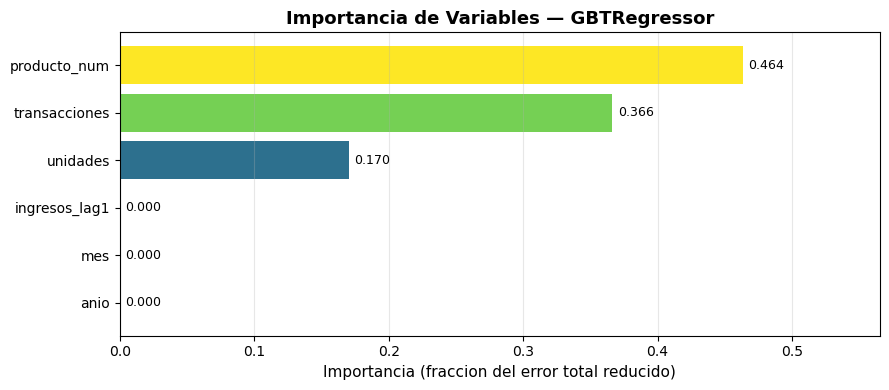


Variable mas importante : 'producto_num' (0.464)
-> Confirma que el historial reciente de ventas predice la demanda futura.


In [8]:
# Pipeline simplificado: stages[0]=assembler, stages[1]=gbt
# Por eso usamos stages[-1] para acceder al GBTRegressionModel
gbt_model = model_gbt.stages[-1]

# Los nombres deben coincidir EXACTAMENTE con el orden de inputCols del assembler
feature_names = ["anio", "mes", "producto_num", "transacciones", "unidades", "ingresos_lag1"]
importancias = (
    pd.DataFrame({
        "Feature":     feature_names,
        "Importancia": gbt_model.featureImportances.toArray()
    })
    .sort_values("Importancia", ascending=True)
)

norm_vals   = importancias["Importancia"] / importancias["Importancia"].max()
colores_vi  = plt.cm.viridis(norm_vals)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(importancias["Feature"], importancias["Importancia"], color=colores_vi)
ax.set_xlabel("Importancia (fraccion del error total reducido)", fontsize=11)
ax.set_title("Importancia de Variables — GBTRegressor", fontsize=13, fontweight="bold")
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=9)
ax.set_xlim(0, importancias["Importancia"].max() * 1.22)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("/home/jovyan/output/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

top_f = importancias.iloc[-1]
print(f"\nVariable mas importante : '{top_f['Feature']}' ({top_f['Importancia']:.3f})")
print("-> Confirma que el historial reciente de ventas predice la demanda futura.")

## 10. Matriz de Confusión — Categorías de Ingreso

### ¿Cómo aplicamos una matriz de confusión a un problema de regresión?
La matriz de confusión es una herramienta de **clasificación** — compara categorías discretas.
Nuestro modelo predice ingresos continuos (regresión). Para usar la CM:

> Convertimos los ingresos continuos en **3 categorías** usando percentiles del conjunto de test:
> - **Bajo** → ingreso ≤ percentil 33
> - **Medio** → percentil 33 < ingreso ≤ percentil 66
> - **Alto** → ingreso > percentil 66

Esta conversión nos permite responder: *¿el modelo identifica correctamente si un producto
va a tener demanda alta, media o baja?* — pregunta directamente útil para el negocio.

### Cómo leer la matriz
```
                     PREDICHO POR EL MODELO
                   ┌────────┬────────┬────────┐
                   │  Bajo  │ Medio  │  Alto  │
       ┌───────────┼────────┼────────┼────────┤
  R    │   Bajo    │   TP   │   FP   │   FP   │ ← Recall Bajo  = TP / fila total
  E    ├───────────┼────────┼────────┼────────┤
  A    │   Medio   │   FN   │   TP   │   FP   │ ← Recall Medio = TP / fila total
  L    ├───────────┼────────┼────────┼────────┤
       │   Alto    │   FN   │   FN   │   TP   │ ← Recall Alto  = TP / fila total
       └───────────┴────────┴────────┴────────┘
```
- **Diagonal (↘)**: predicciones correctas — el modelo acertó la categoría
- **Adyacente a diagonal**: error leve — se confundió un nivel (Bajo↔Medio, Medio↔Alto)
- **Esquinas**: error grave — predijo Alto cuando era Bajo o viceversa

Umbral Bajo  → Medio  : S/ 635.15  (percentil 33)
Umbral Medio → Alto   : S/ 3,125.83  (percentil 66)

Distribución real : {'Alto': 5, 'Bajo': 5, 'Medio': 4}
Distribución pred : {'Bajo': 6, 'Medio': 5, 'Alto': 3}


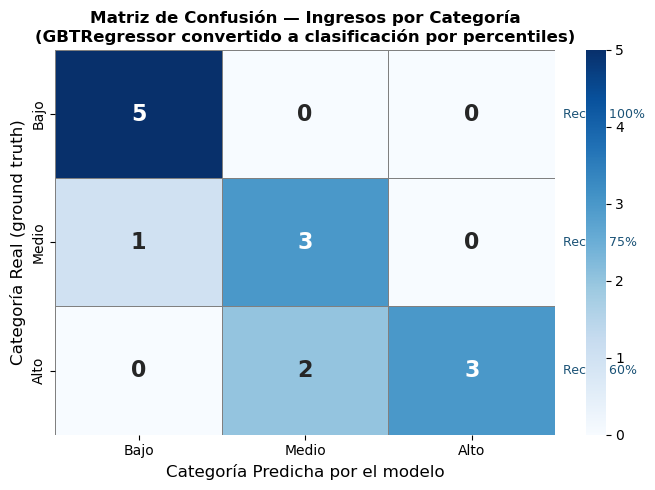


Accuracy de clasificación : 78.6%
(% de productos cuya categoría de ingreso fue predicha correctamente)

Lectura de la matriz:
  → Diagonal principal (↘): predicciones CORRECTAS
  → Celdas adyacentes (Bajo↔Medio, Medio↔Alto): errores LEVES (un rango de diferencia)
  → Esquinas (Bajo↔Alto): errores GRAVES (clasificación completamente opuesta)


In [9]:
# ── Umbrales por percentil 33 y 66 — se adaptan a la escala real de los datos ──
# Si usáramos umbrales fijos (e.g. Bajo < 2000) pueden quedarse obsoletos si cambian los precios.
# Con percentiles, siempre habrá exactamente ~33% en cada categoría.
p33 = pred_test["ingresos"].quantile(0.33)
p66 = pred_test["ingresos"].quantile(0.66)

print(f"Umbral Bajo  → Medio  : S/ {p33:,.2f}  (percentil 33)")
print(f"Umbral Medio → Alto   : S/ {p66:,.2f}  (percentil 66)")

def categorizar(val):
    if val <= p33:   return "Bajo"
    elif val <= p66: return "Medio"
    else:            return "Alto"

pred_test["cat_real"] = pred_test["ingresos"].apply(categorizar)
pred_test["cat_pred"] = pred_test["prediction"].apply(categorizar)

print(f"\nDistribución real : {pred_test['cat_real'].value_counts().to_dict()}")
print(f"Distribución pred : {pred_test['cat_pred'].value_counts().to_dict()}")

# ── Calcular la Confusion Matrix ───────────────────────────────────────────────
# labels fija el orden de las filas/columnas: Bajo=0, Medio=1, Alto=2
labels = ["Bajo", "Medio", "Alto"]
cm = confusion_matrix(pred_test["cat_real"], pred_test["cat_pred"], labels=labels)

# ── Heatmap con seaborn ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=labels, yticklabels=labels,
    linewidths=0.5, linecolor="gray",
    ax=ax, annot_kws={"size": 16, "weight": "bold"}
)
ax.set_xlabel("Categoría Predicha por el modelo", fontsize=12)
ax.set_ylabel("Categoría Real (ground truth)", fontsize=12)
ax.set_title(
    "Matriz de Confusión — Ingresos por Categoría\n"
    "(GBTRegressor convertido a clasificación por percentiles)",
    fontsize=12, fontweight="bold"
)

# Anotar Recall por clase en el margen derecho
for i, label in enumerate(labels):
    total_real = cm[i].sum()
    if total_real > 0:
        recall = cm[i, i] / total_real
        ax.text(3.05, i + 0.5, f"Recall: {recall:.0%}", va="center", fontsize=9, color="#1a5276")

plt.tight_layout()
plt.savefig("/home/jovyan/output/confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Resumen numérico ──────────────────────────────────────────────────────────
accuracy = np.trace(cm) / cm.sum()
print(f"\nAccuracy de clasificación : {accuracy:.1%}")
print("(% de productos cuya categoría de ingreso fue predicha correctamente)")
print("\nLectura de la matriz:")
print("  → Diagonal principal (↘): predicciones CORRECTAS")
print("  → Celdas adyacentes (Bajo↔Medio, Medio↔Alto): errores LEVES (un rango de diferencia)")
print("  → Esquinas (Bajo↔Alto): errores GRAVES (clasificación completamente opuesta)")

## 11. Predicción 2026 — ¿Qué productos dominarán cada mes?

### Estrategia de predicción futura
Para predecir los 12 meses de 2026:
1. Tomamos los **top 15 productos** por ingresos históricos totales
2. Generamos todas las combinaciones `producto × mes` (15 × 12 = 180 filas)
3. Aproximamos `ingresos_lag1` con el **promedio histórico** de ingresos por producto
   *(en producción real, este valor se actualizaría cada mes con datos reales del mes anterior)*
4. El modelo GBT aplica lo aprendido para estimar el ingreso de cada combinación

### ¿Qué visualizamos?
- **Gráfico de barras**: ranking anual de los top 10 productos (suma de los 12 meses)
- **Gráfico de líneas**: evolución mes a mes de los top 5 productos
  → Permite detectar si el modelo capturó estacionalidad (picos en ciertos meses)

In [ ]:
# ── Top 15 productos por ingresos históricos totales ──────────────────────────
top15_prod = (
    agg_enc.groupBy("producto")
    .agg(spark_sum("ingresos").alias("hist_total"))
    .orderBy(col("hist_total").desc())
    .limit(15)
)

# ── Promedios históricos por producto (aproximan lag en meses futuros) ─────────
promedios = (
    agg_enc.groupBy("producto")
    .agg(
        avg("transacciones").alias("transacciones"),
        avg("unidades").alias("unidades"),
        avg("ingresos").alias("ingresos_lag1"),
    )
)

# ── Dataset futuro: top15 x 12 meses de 2026 ──────────────────────────────────
meses_2026 = spark.createDataFrame([(float(m),) for m in range(1, 13)], ["mes"])

futuro = (
    top15_prod.select("producto")
    .crossJoin(meses_2026)
    .join(promedios, "producto", "left")
    .join(prod_df, "producto", "left")   # producto_num necesario para el modelo
    .withColumn("anio",     lit(2026.0))
    .withColumn("ingresos", lit(0.0))    # placeholder requerido por el pipeline
)

pred_2026 = model_gbt.transform(futuro)

# ── Ranking anual ──────────────────────────────────────────────────────────────
ranking_2026 = (
    pred_2026
    .groupBy("producto")
    .agg(spark_round(spark_sum("prediction"), 2).alias("ingresos_pred_2026"))
    .orderBy(col("ingresos_pred_2026").desc())
    .toPandas()
)

print("============ TOP 15 PRODUCTOS PREDICHOS PARA 2026 ============")
print(ranking_2026.to_string(index=False))

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# ── Panel izquierdo: ranking anual barras ──────────────────────────────────────
top10_plot = ranking_2026.head(10)
bars = axes[0].barh(top10_plot["producto"], top10_plot["ingresos_pred_2026"], color="darkorange")
axes[0].set_xlabel("Ingresos predichos 2026 (S/)", fontsize=11)
axes[0].set_title("Top 10 Productos — Predicción Anual 2026", fontsize=13, fontweight="bold")
axes[0].invert_yaxis()
axes[0].grid(axis="x", alpha=0.3)
for bar, val in zip(axes[0].patches, top10_plot["ingresos_pred_2026"]):
    axes[0].text(
        bar.get_width() + 200,
        bar.get_y() + bar.get_height() / 2,
        f"S/ {val:,.0f}", va="center", fontsize=8
    )

# ── Panel derecho: evolución mes a mes de los top 5 ───────────────────────────
top5 = ranking_2026.head(5)["producto"].tolist()
pred_mes = (
    pred_2026
    .filter(col("producto").isin(top5))
    .select("producto", "mes", "prediction")
    .toPandas()
    .sort_values("mes")
)

meses_labels = ["Ene","Feb","Mar","Abr","May","Jun","Jul","Ago","Sep","Oct","Nov","Dic"]
colores = plt.cm.tab10.colors

for i, prod in enumerate(top5):
    data = pred_mes[pred_mes["producto"] == prod]
    axes[1].plot(
        data["mes"], data["prediction"],
        marker="o", label=prod[:22],
        color=colores[i], linewidth=2, markersize=5
    )

axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(meses_labels, rotation=45)
axes[1].set_xlabel("Mes 2026", fontsize=11)
axes[1].set_ylabel("Ingresos Predichos (S/)", fontsize=11)
axes[1].set_title("Evolución Mensual 2026 — Top 5 Productos", fontsize=13, fontweight="bold")
axes[1].legend(fontsize=8, loc="upper left")
axes[1].grid(alpha=0.3)

plt.suptitle("Forecast de Ventas 2026 — Casa Market", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("/home/jovyan/output/forecast_2026.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado → output/forecast_2026.png")

## 6. Guardar modelo

In [ ]:
MODEL_PATH = '/home/jovyan/output/modelo_ventas_2026'
model_gbt.write().overwrite().save(MODEL_PATH)
print(f'Modelo GBT guardado en {MODEL_PATH}')
print('Para cargarlo:')
print('  from pyspark.ml import PipelineModel')
print('  model = PipelineModel.load("/home/jovyan/output/modelo_ventas_2026")')